In [ ]:
import pandas as pd

df = pd.read_csv("dataset 2.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (35717, 4)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


**Does our dataset have missing values or duplicate rows?**

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
SystemCodeNumber    0
Capacity            0
Occupancy           0
LastUpdated         0
dtype: int64

Duplicate Rows:
216


**Statistical summary**

In [ ]:
df.describe()

,Capacity,Occupancy
count,35717.000000,35717.000000
mean,1397.550130,642.228911
std,1179.326833,656.955535
min,220.000000,-8.000000
25%,500.000000,210.000000
50%,849.000000,446.000000
75%,2009.000000,798.000000
max,4675.000000,4327.000000


In [ ]:
print("Negative Occupancy Values:")
print((df["Occupancy"] < 0).sum())

Negative Occupancy Values:
12


In [ ]:
df[df["Occupancy"] < 0]

,SystemCodeNumber,Capacity,Occupancy,LastUpdated
23889,NIA North,480,-3,2016-10-16 15:57:16
23890,NIA North,480,-3,2016-10-16 16:31:17
23906,NIA North,480,-1,2016-10-18 15:27:59
23919,NIA North,480,-8,2016-10-28 13:02:43
23924,NIA North,480,-1,2016-10-28 15:29:41
23925,NIA North,480,-4,2016-10-28 16:02:40
23926,NIA North,480,-1,2016-10-28 16:29:42
23937,NIA North,480,-2,2016-10-29 12:59:51
23944,NIA North,480,-1,2016-10-29 16:26:53
23997,NIA North,480,-3,2016-11-10 16:00:15


In [ ]:
print("Number of parking locations:", df["SystemCodeNumber"].nunique())

Number of parking locations: 30


In [ ]:
print(df["SystemCodeNumber"].unique())

['BHMBCCMKT01' 'BHMBCCPST01' 'BHMBCCSNH01' 'BHMBCCTHL01' 'BHMBRCBRG01'
 'BHMBRCBRG02' 'BHMBRCBRG03' 'BHMBRTARC01' 'BHMEURBRD01' 'BHMEURBRD02'
 'BHMMBMMBX01' 'BHMNCPHST01' 'BHMNCPLDH01' 'BHMNCPNHS01' 'BHMNCPNST01'
 'BHMNCPPLS01' 'BHMNCPRAN01' 'Broad Street' 'Bull Ring' 'NIA Car Parks'
 'NIA North' 'NIA South' 'Others-CCCPS105a' 'Others-CCCPS119a'
 'Others-CCCPS133' 'Others-CCCPS135a' 'Others-CCCPS202' 'Others-CCCPS8'
 'Others-CCCPS98' 'Shopping']


**EDA: Average occupancy at each parking location**

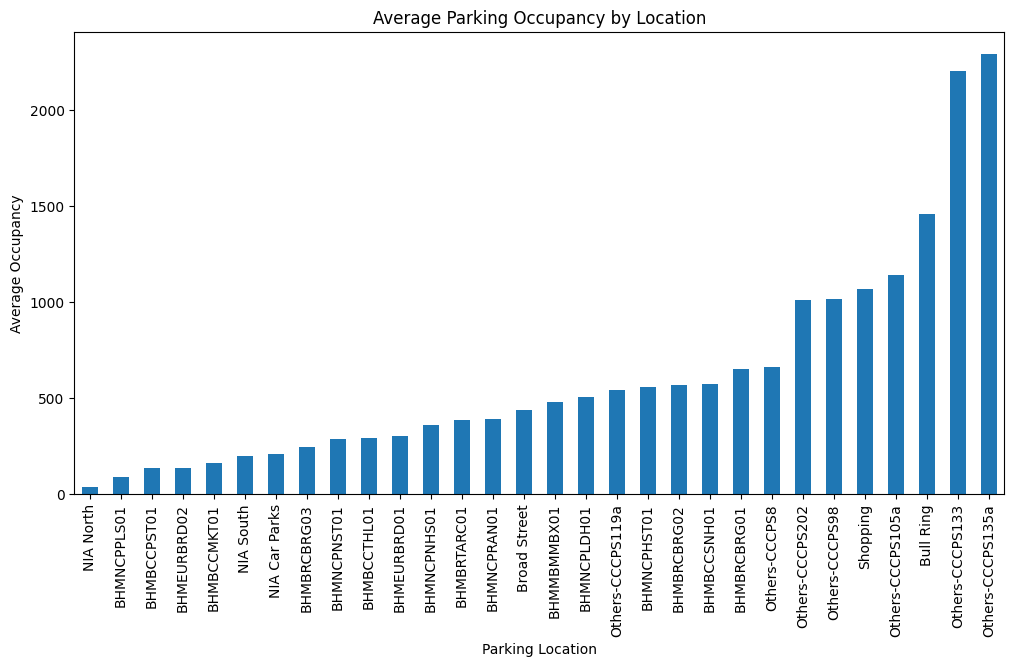

In [ ]:
import matplotlib.pyplot as plt

location_occupancy = df.groupby("SystemCodeNumber")["Occupancy"].mean()

plt.figure(figsize=(12,6))
location_occupancy.sort_values().plot(kind="bar")

plt.xlabel("Parking Location")
plt.ylabel("Average Occupancy")
plt.title("Average Parking Occupancy by Location")

plt.xticks(rotation=90)
plt.show()

The taller bars = locations with higher average occupancy.

The shorter bars = locations with lower average occupancy.

**At what time of day is parking occupancy higher?**

In [ ]:
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

df["Hour"] = df["LastUpdated"].dt.hour

print(df[["LastUpdated", "Hour"]].head())

          LastUpdated  Hour
0 2016-10-04 07:59:42     7
1 2016-10-04 08:25:42     8
2 2016-10-04 08:59:42     8
3 2016-10-04 09:32:46     9
4 2016-10-04 09:59:48     9


**Whether parking occupancy changes with time.**

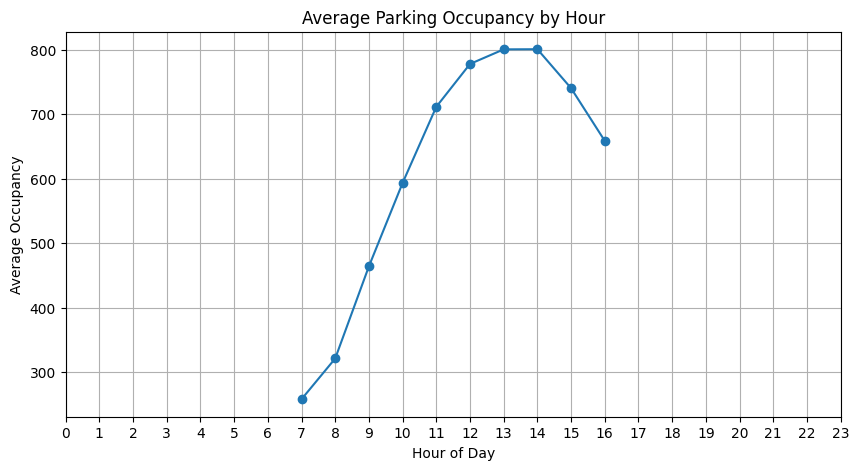

In [ ]:
hourly_occupancy = df.groupby("Hour")["Occupancy"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_occupancy.index, hourly_occupancy.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.title("Average Parking Occupancy by Hour")

plt.xticks(range(24))
plt.grid()
plt.show()

**Does parking capacity have a relationship with occupancy?**

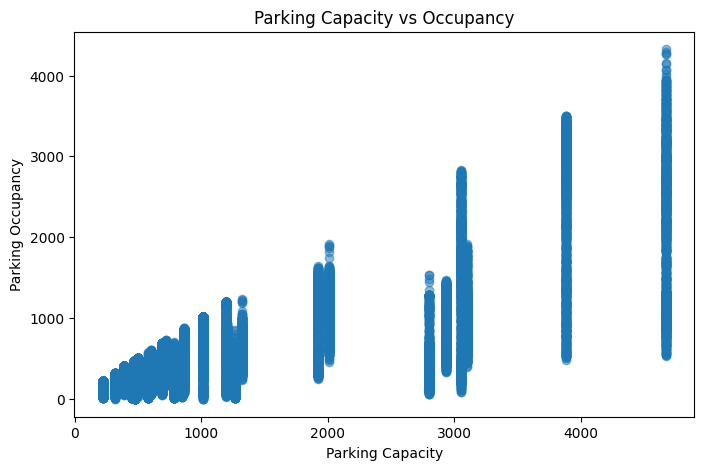

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Capacity"], df["Occupancy"], alpha=0.5)

plt.xlabel("Parking Capacity")
plt.ylabel("Parking Occupancy")
plt.title("Parking Capacity vs Occupancy")

plt.show()

X-axis → total parking spaces available

Y-axis → number of occupied spaces

Each dot → one record from our dataset

**Correlation**

In [ ]:
correlation = df[["Capacity", "Occupancy", "Hour"]].corr()

print(correlation)

           Capacity  Occupancy      Hour
Capacity   1.000000   0.775825  0.002229
Occupancy  0.775825   1.000000  0.199852
Hour       0.002229   0.199852  1.000000


           Capacity  Occupancy      Hour
Capacity   1.000000   0.775825  0.002229
Occupancy  0.775825   1.000000  0.199852
Hour       0.002229   0.199852  1.000000


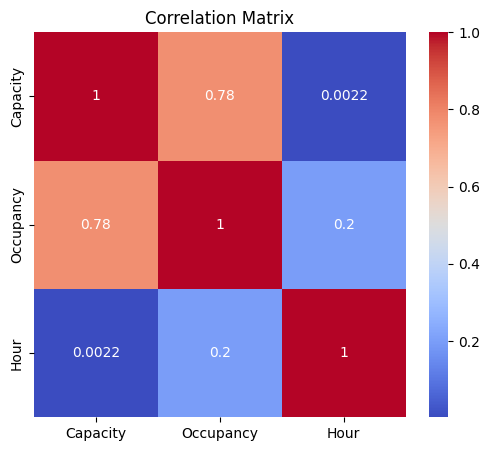

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[["Capacity", "Occupancy", "Hour"]].corr()

print(correlation)

plt.figure(figsize=(6,5))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

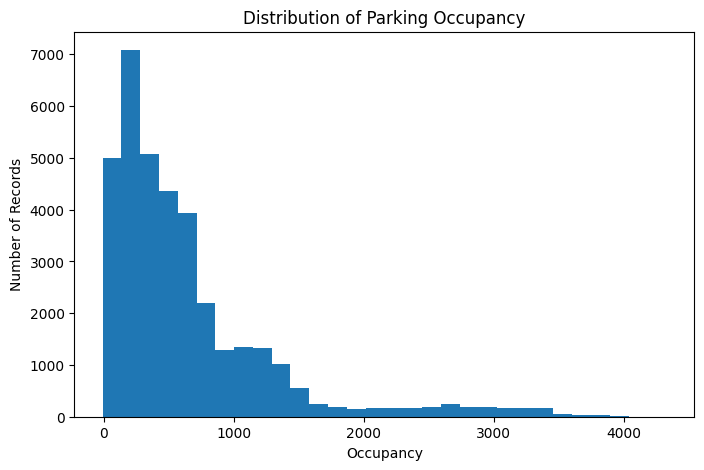

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Occupancy"], bins=30)

plt.xlabel("Occupancy")
plt.ylabel("Number of Records")
plt.title("Distribution of Parking Occupancy")

plt.show()

X-axis → number of occupied parking spaces

Y-axis → how many records have that occupancy

It helps us see whether most observations have low, medium, or high occupancy.

**Data Preprocessing**

In [ ]:
df = df[df["Occupancy"] >= 0].copy()

print("Dataset shape after cleaning:", df.shape)
print("Negative occupancy values:", (df["Occupancy"] < 0).sum())

Dataset shape after cleaning: (35705, 6)
Negative occupancy values: 0


In [ ]:
# Select input features
X = df[[
    "SystemCodeNumber",
    "Capacity",
    "Hour"
]]

# Select target
y = df["Occupancy"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
  SystemCodeNumber  Capacity  Hour
0      BHMBCCMKT01       577     7
1      BHMBCCMKT01       577     8
2      BHMBCCMKT01       577     8
3      BHMBCCMKT01       577     9
4      BHMBCCMKT01       577     9

Target:
0     61
1     64
2     80
3    107
4    150
Name: Occupancy, dtype: int64


In [ ]:
import pandas as pd

df = pd.read_csv("dataset 2.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (35717, 4)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


In [ ]:
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

# Remove invalid negative occupancy values
df = df[df["Occupancy"] >= 0].copy()

# Extract hour
df["Hour"] = df["LastUpdated"].dt.hour

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (35705, 5)


Elastic Net Regression
----------------------
MAE : 229.76701359360058
RMSE: 341.16661375917914
R2 Score: 0.7178152772928668

Sample Predictions:
   Actual Occupancy  Predicted Occupancy
0               237          1137.260917
1               201           125.552907
2              1055           862.622638
3                87           392.426601
4               330           243.479298
5               179           249.386663
6               419           479.176657
7               575          1124.567556
8               842           691.291151
9               425           452.891256


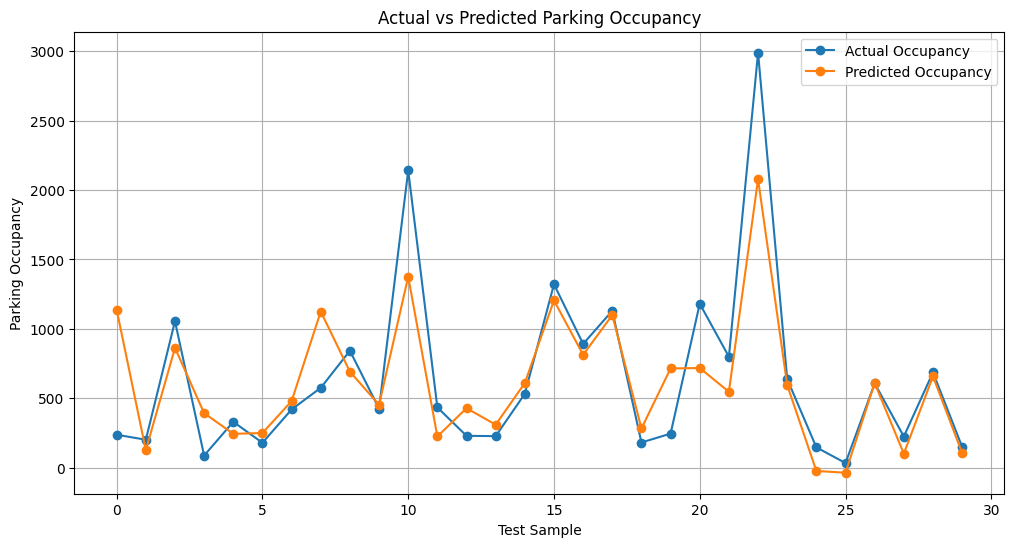

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Input features and target
X = df[[
    "SystemCodeNumber",
    "Capacity",
    "Hour"
]]

y = df["Occupancy"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("location",
         OneHotEncoder(handle_unknown="ignore"),
         ["SystemCodeNumber"])
    ],
    remainder=StandardScaler()
)

# Elastic Net Regression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ))
])

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Elastic Net Regression")
print("----------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Sample predictions
results = pd.DataFrame({
    "Actual Occupancy": y_test.values,
    "Predicted Occupancy": y_pred
})

print("\nSample Predictions:")
print(results.head(10))

# Graph
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:30],
    marker="o",
    label="Actual Occupancy"
)

plt.plot(
    y_pred[:30],
    marker="o",
    label="Predicted Occupancy"
)

plt.xlabel("Test Sample")
plt.ylabel("Parking Occupancy")
plt.title("Actual vs Predicted Parking Occupancy")
plt.legend()
plt.grid(True)
plt.show()